# Customer Churn Analysis — Exploratory Data Analysis

## Objective

The objective of this notebook is to analyze customer churn patterns in a telecom dataset and identify the key business drivers behind customer attrition.

This analysis focuses on:

- Overall churn rate
- Churn by contract type
- Churn by tenure
- Churn by monthly charges
- Revenue risk
- Business recommendations for customer retention

In [47]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

In [48]:
BASE_DIR = Path.cwd().parent

DATA_PATH = BASE_DIR / "data" / "raw" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
IMAGE_DIR = BASE_DIR / "images"

IMAGE_DIR.mkdir(exist_ok=True)

print("Base directory:", BASE_DIR)
print("Data path:", DATA_PATH)
print("Image directory:", IMAGE_DIR)

Base directory: c:\Users\HP\Desktop\customer-churn-retention-analytics
Data path: c:\Users\HP\Desktop\customer-churn-retention-analytics\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv
Image directory: c:\Users\HP\Desktop\customer-churn-retention-analytics\images


In [49]:
df = pd.read_csv(DATA_PATH)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [50]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 7043
Columns: 21


In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [52]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [53]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

missing_total_charges = df["TotalCharges"].isnull().sum()
missing_total_charges

np.int64(11)

In [54]:
df = df.dropna(subset=["TotalCharges"])

print("Rows after cleaning:", df.shape[0])
print("Columns after cleaning:", df.shape[1])

Rows after cleaning: 7032
Columns after cleaning: 21


In [55]:
churn_counts = df["Churn"].value_counts()
churn_percentage = df["Churn"].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "Customer Count": churn_counts,
    "Percentage": churn_percentage.round(2)
})

target_summary

,Customer Count,Percentage
Churn,,
No,5163,73.42
Yes,1869,26.58


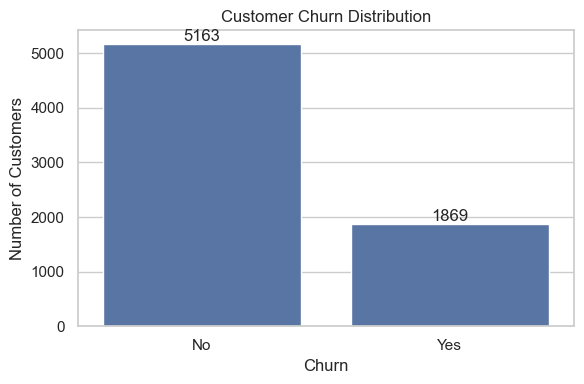

In [56]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.savefig(IMAGE_DIR / "01_churn_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

 Insight: Overall Churn Rate

Approximately 26.6% of customers have churned. This indicates a meaningful retention problem because more than one out of every four customers is leaving the company.

In [57]:
contract_churn = (
    df.groupby("Contract")
    .agg(
        total_customers=("customerID", "count"),
        churned_customers=("Churn", lambda x: (x == "Yes").sum()),
        avg_monthly_charges=("MonthlyCharges", "mean")
    )
)

contract_churn["churn_rate_percentage"] = (
    contract_churn["churned_customers"] / contract_churn["total_customers"] * 100
).round(2)

contract_churn = contract_churn.sort_values("churn_rate_percentage", ascending=False)

contract_churn

,total_customers,churned_customers,avg_monthly_charges,churn_rate_percentage
Contract,,,,
Month-to-month,3875,1655,66.398490,42.71
One year,1472,166,65.079416,11.28
Two year,1685,48,60.872374,2.85


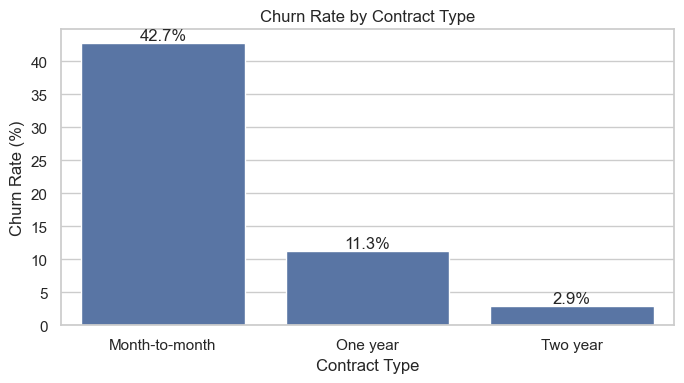

In [58]:
plt.figure(figsize=(7, 4))

ax = sns.barplot(
    data=contract_churn.reset_index(),
    x="Contract",
    y="churn_rate_percentage"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.savefig(IMAGE_DIR / "02_churn_by_contract.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight: Contract Type Is a Major Churn Driver

Month-to-month customers show the highest churn rate compared to one-year and two-year contract customers. This suggests that customers without long-term commitment are more likely to leave, making them a priority segment for retention campaigns.

In [59]:
monthly_charge_summary = df.groupby("Churn")["MonthlyCharges"].describe()

monthly_charge_summary

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,61.307408,31.094557,18.25,25.10,64.45,88.475,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.65,94.200,118.35


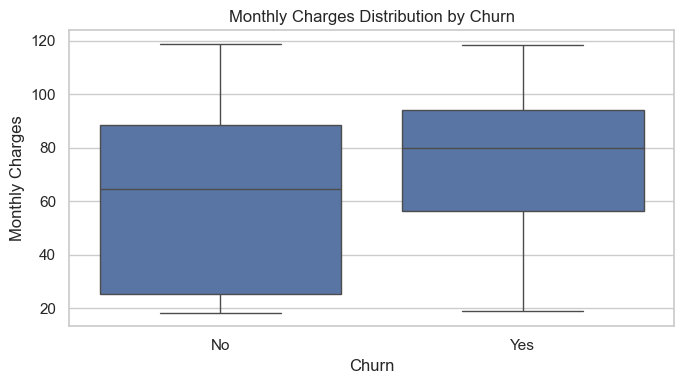

In [60]:
plt.figure(figsize=(7, 4))

sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.savefig(IMAGE_DIR / "03_monthly_charges_by_churn.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight: Higher Monthly Charges Are Linked With Churn

Customers who churn tend to have higher monthly charges. This may indicate price sensitivity, especially among customers who are not locked into long-term contracts.

In [61]:
tenure_summary = df.groupby("Churn")["tenure"].describe()

tenure_summary

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,37.650010,24.076940,1.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


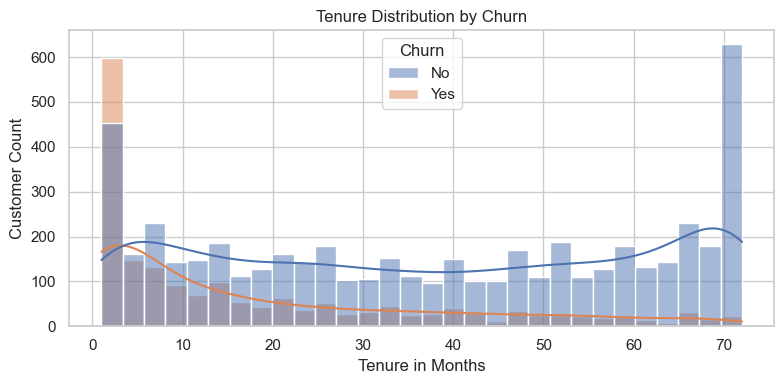

In [62]:
plt.figure(figsize=(8, 4))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure in Months")
plt.ylabel("Customer Count")

plt.tight_layout()
plt.savefig(IMAGE_DIR / "04_tenure_distribution_by_churn.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight: Newer Customers Are More Likely to Churn

Customers with lower tenure are more likely to churn. This shows that the early customer lifecycle is a critical period for retention.

In [63]:
def tenure_bucket(tenure):
    if tenure <= 12:
        return "0-12 months"
    elif tenure <= 24:
        return "13-24 months"
    elif tenure <= 48:
        return "25-48 months"
    else:
        return "48+ months"

df["TenureBucket"] = df["tenure"].apply(tenure_bucket)

df[["tenure", "TenureBucket"]].head()

,tenure,TenureBucket
0,1,0-12 months
1,34,25-48 months
2,2,0-12 months
3,45,25-48 months
4,2,0-12 months


In [64]:
tenure_bucket_churn = (
    df.groupby("TenureBucket")
    .agg(
        total_customers=("customerID", "count"),
        churned_customers=("Churn", lambda x: (x == "Yes").sum())
    )
)

tenure_bucket_churn["churn_rate_percentage"] = (
    tenure_bucket_churn["churned_customers"] / tenure_bucket_churn["total_customers"] * 100
).round(2)

tenure_order = ["0-12 months", "13-24 months", "25-48 months", "48+ months"]
tenure_bucket_churn = tenure_bucket_churn.loc[tenure_order]

tenure_bucket_churn

,total_customers,churned_customers,churn_rate_percentage
TenureBucket,,,
0-12 months,2175,1037,47.68
13-24 months,1024,294,28.71
25-48 months,1594,325,20.39
48+ months,2239,213,9.51


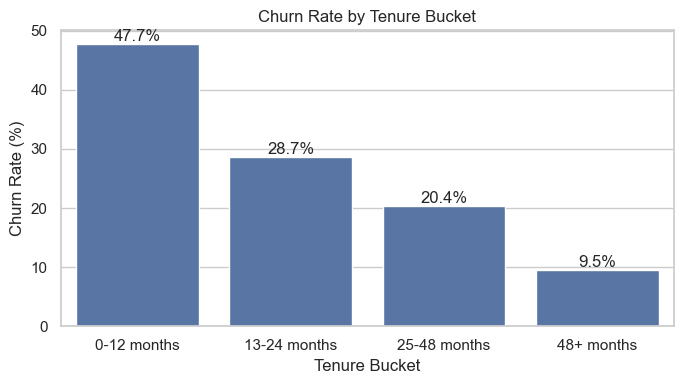

In [66]:
plt.figure(figsize=(7, 4))

ax = sns.barplot(
    data=tenure_bucket_churn.reset_index(),
    x="TenureBucket",
    y="churn_rate_percentage"
)

plt.title("Churn Rate by Tenure Bucket")
plt.xlabel("Tenure Bucket")
plt.ylabel("Churn Rate (%)")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.tight_layout()
plt.savefig(IMAGE_DIR / "05_churn_by_tenure_bucket.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight: First-Year Customers Need Retention Focus

The highest churn occurs among customers in the first 12 months. This suggests the company should introduce onboarding support, loyalty offers, or early engagement campaigns during the first year.

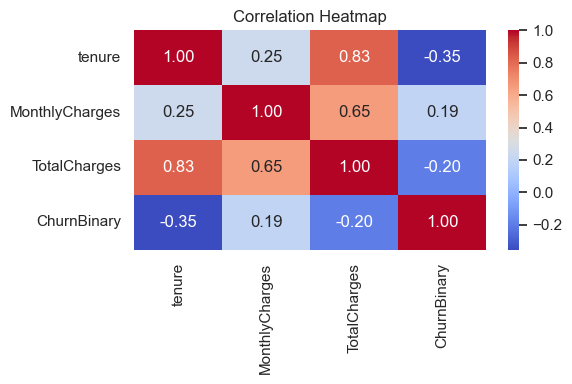

In [67]:
df_corr = df.copy()
df_corr["ChurnBinary"] = df_corr["Churn"].map({"Yes": 1, "No": 0})

numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "ChurnBinary"]

corr = df_corr[numeric_cols].corr()

plt.figure(figsize=(6, 4))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.savefig(IMAGE_DIR / "06_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

### Insight: Tenure Has a Negative Relationship With Churn

Tenure has a negative relationship with churn, meaning customers who stay longer are less likely to leave. TotalCharges is strongly related to tenure and MonthlyCharges, so it should be handled carefully during feature engineering to avoid redundant information.

In [68]:
summary = pd.DataFrame({
    "Finding": [
        "Month-to-month contracts have the highest churn",
        "New customers have higher churn risk",
        "Customers with higher monthly charges churn more",
        "Tenure is negatively related to churn",
        "Revenue at risk can be reduced through targeted retention"
    ],
    "Business Recommendation": [
        "Offer discounts or benefits to convert month-to-month users into annual contracts",
        "Create onboarding and engagement campaigns for first-year customers",
        "Provide loyalty offers to high-charge customers",
        "Focus retention campaigns before customers reach the high-risk churn period",
        "Prioritize high-value customers with high churn probability"
    ]
})

summary

,Finding,Business Recommendation
0,Month-to-month contracts have the highest churn,Offer discounts or benefits to convert month-t...
1,New customers have higher churn risk,Create onboarding and engagement campaigns for...
2,Customers with higher monthly charges churn more,Provide loyalty offers to high-charge customers
3,Tenure is negatively related to churn,Focus retention campaigns before customers rea...
4,Revenue at risk can be reduced through targete...,Prioritize high-value customers with high chur...


In [69]:
processed_path = BASE_DIR / "data" / "processed" / "telco_churn_cleaned.csv"

df.to_csv(processed_path, index=False)

print(f"Cleaned dataset saved to: {processed_path}")

Cleaned dataset saved to: c:\Users\HP\Desktop\customer-churn-retention-analytics\data\processed\telco_churn_cleaned.csv
